In [1]:

import os
import time
import copy
import json
import random
import gc
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import label_binarize


In [2]:

DATA_DIR = "/kaggle/input/datasets/lfreedom2750/mcvsld-split-version"

SEED = 42
BATCH_SIZE = 64
IMAGE_SIZE = 224
NUM_WORKERS = 2

# Training can be long because this notebook searches more optimizer/LR configs.
MAX_EPOCHS = 50
MAX_CONFIGS_TO_RUN = None  # Example: set 4 for a quick smoke test.

USE_CLASS_WEIGHTS = True
LABEL_SMOOTHING = 0.05
USE_AMP = True

EARLY_STOPPING_PATIENCE = 7
LR_PATIENCE = 3
LR_FACTOR = 0.5

SAVE_DIR = Path("experiments/resnet18_optimizer_lr_search_v2")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Keep benchmark on for speed when input sizes are fixed.
    torch.backends.cudnn.benchmark = True


set_seed(SEED)


Using device: cuda


In [3]:

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.75, 1.0),
        ratio=(0.85, 1.15)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(
        p=0.15,
        scale=(0.02, 0.12),
        ratio=(0.3, 3.3),
        value="random"
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.15)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [4]:

train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=train_transform
)

train_eval_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=eval_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "val"),
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "test"),
    transform=eval_transform
)

PIN_MEMORY = DEVICE.type == "cuda"
PERSISTENT_WORKERS = NUM_WORKERS > 0


def make_loader(dataset, shuffle):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS
    )


train_loader = make_loader(train_dataset, shuffle=True)
train_eval_loader = make_loader(train_eval_dataset, shuffle=False)
val_loader = make_loader(val_dataset, shuffle=False)
test_loader = make_loader(test_dataset, shuffle=False)

CLASS_NAMES = train_dataset.classes
CLASS_TO_IDX = train_dataset.class_to_idx
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Class to index:", CLASS_TO_IDX)
print("Num classes:", NUM_CLASSES)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Classes: ['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']
Class to index: {'Chickenpox': 0, 'Cowpox': 1, 'HFMD': 2, 'Healthy': 3, 'Measles': 4, 'Monkeypox': 5}
Num classes: 6
Train samples: 602
Val samples: 74
Test samples: 79


In [5]:

def count_per_class(dataset):
    counts = {}

    for _, label in dataset.samples:
        class_name = dataset.classes[label]
        counts[class_name] = counts.get(class_name, 0) + 1

    return counts


train_counts = count_per_class(train_dataset)
val_counts = count_per_class(val_dataset)
test_counts = count_per_class(test_dataset)

stats_df = pd.DataFrame({
    "train": pd.Series(train_counts),
    "val": pd.Series(val_counts),
    "test": pd.Series(test_counts)
}).fillna(0).astype(int)

stats_df["total"] = stats_df.sum(axis=1)

train_class_counts = np.array(
    [train_counts[class_name] for class_name in CLASS_NAMES],
    dtype=np.float32
)

class_weights = train_class_counts.sum() / (NUM_CLASSES * train_class_counts)
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
) if USE_CLASS_WEIGHTS else None

stats_df["class_weight"] = class_weights

display(stats_df)

if USE_CLASS_WEIGHTS:
    print("Using class weights:", class_weights_tensor.detach().cpu().numpy())
else:
    print("Class weights disabled.")


,train,val,test,total,class_weight
Chickenpox,60,7,8,75,1.672222
Cowpox,52,7,7,66,1.929487
HFMD,128,16,17,161,0.783854
Healthy,91,11,12,114,1.102564
Measles,44,5,6,55,2.280303
Monkeypox,227,28,29,284,0.441997


Using class weights: [1.6722223  1.9294872  0.7838542  1.1025641  2.280303   0.44199705]


In [6]:

from torchvision import models
from torchvision.models import ResNet18_Weights
import torch.nn as nn


def create_model(num_classes):
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, num_classes)
    )

    return model


In [7]:

def format_epoch_time(seconds):
    minutes = int(seconds // 60)
    secs = seconds % 60

    if minutes > 0:
        return f"{minutes}m {secs:.0f}s"

    return f"{secs:.0f}s"


def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None, use_amp=False):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    amp_enabled = bool(use_amp and device.type == "cuda")

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if scaler is not None and amp_enabled:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def compute_specificity_multiclass(conf_matrix):
    specificities = []

    for i in range(conf_matrix.shape[0]):
        tp = conf_matrix[i, i]
        fn = conf_matrix[i, :].sum() - tp
        fp = conf_matrix[:, i].sum() - tp
        tn = conf_matrix.sum() - (tp + fn + fp)

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(specificity)

    return float(np.mean(specificities)), specificities


def evaluate_model(model, loader, criterion, device, num_classes, use_amp=False):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []
    y_prob = []

    amp_enabled = bool(use_amp and device.type == "cuda")

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=amp_enabled):
                outputs = model(images)
                loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            running_loss += loss.item() * images.size(0)
            total_samples += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.float().cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    avg_loss = running_loss / total_samples

    cm = confusion_matrix(y_true, y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)

    specificity_macro, specificity_per_class = compute_specificity_multiclass(cm)

    try:
        y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
        roc_auc = roc_auc_score(
            y_true_bin,
            y_prob,
            multi_class="ovr",
            average="macro"
        )
    except ValueError:
        roc_auc = None

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "roc_auc_macro_ovr": roc_auc,
        "sensitivity_macro": recall,
        "specificity_macro": specificity_macro,
        "specificity_per_class": specificity_per_class,
        "mcc": mcc,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }


In [8]:

def create_optimizer(model, config):
    optimizer_name = config["optimizer"]
    lr = config["lr"]
    weight_decay = config.get("weight_decay", 0.0)

    if optimizer_name == "Adam":
        optimizer = optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    elif optimizer_name == "SGD":
        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=config.get("momentum", 0.9),
            weight_decay=weight_decay,
            nesterov=config.get("nesterov", True)
        )

    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(
            model.parameters(),
            lr=lr,
            momentum=config.get("momentum", 0.9),
            weight_decay=weight_decay,
            alpha=config.get("alpha", 0.99)
        )

    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    return optimizer


In [9]:

def format_float_for_name(value):
    return f"{value:.0e}".replace("-", "m").replace("+", "")


def build_experiment_configs():
    specs = [
        {
            "optimizer": "Adam",
            "lrs": [1e-3, 3e-4, 1e-4, 3e-5],
            "weight_decay": 0.0
        },
        {
            "optimizer": "AdamW",
            "lrs": [1e-3, 3e-4, 1e-4, 3e-5],
            "weight_decay": 1e-4
        },
        {
            "optimizer": "SGD",
            "lrs": [1e-2, 3e-3, 1e-3, 3e-4],
            "momentum": 0.9,
            "weight_decay": 1e-4,
            "nesterov": True
        },
        {
            "optimizer": "RMSprop",
            "lrs": [3e-4, 1e-4, 3e-5],
            "momentum": 0.9,
            "weight_decay": 1e-4,
            "alpha": 0.99
        }
    ]

    configs = []

    for spec in specs:
        for lr in spec["lrs"]:
            config = {key: value for key, value in spec.items() if key != "lrs"}
            config["lr"] = lr
            config["run_name"] = (
                f"{config['optimizer']}_"
                f"lr{format_float_for_name(lr)}_"
                f"wd{format_float_for_name(config.get('weight_decay', 0.0))}"
            )
            configs.append(config)

    return configs


experiment_configs = build_experiment_configs()

if MAX_CONFIGS_TO_RUN is not None:
    experiment_configs = experiment_configs[:MAX_CONFIGS_TO_RUN]

configs_df = pd.DataFrame(experiment_configs)
display(configs_df)

config_path = SAVE_DIR / "experiment_configs.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(experiment_configs, f, indent=2)

print(f"Total configs for resnet18: {len(experiment_configs)}")
print("Saved configs:", config_path)


,optimizer,weight_decay,lr,run_name,momentum,nesterov,alpha
0,Adam,0.0000,0.00100,Adam_lr1em03_wd0e00,NaN,NaN,NaN
1,Adam,0.0000,0.00030,Adam_lr3em04_wd0e00,NaN,NaN,NaN
2,Adam,0.0000,0.00010,Adam_lr1em04_wd0e00,NaN,NaN,NaN
3,Adam,0.0000,0.00003,Adam_lr3em05_wd0e00,NaN,NaN,NaN
4,AdamW,0.0001,0.00100,AdamW_lr1em03_wd1em04,NaN,NaN,NaN
5,AdamW,0.0001,0.00030,AdamW_lr3em04_wd1em04,NaN,NaN,NaN
6,AdamW,0.0001,0.00010,AdamW_lr1em04_wd1em04,NaN,NaN,NaN
7,AdamW,0.0001,0.00003,AdamW_lr3em05_wd1em04,NaN,NaN,NaN
8,SGD,0.0001,0.01000,SGD_lr1em02_wd1em04,0.9,True,NaN
9,SGD,0.0001,0.00300,SGD_lr3em03_wd1em04,0.9,True,NaN


Total configs for resnet18: 15
Saved configs: experiments/resnet18_optimizer_lr_search_v2/experiment_configs.json


In [10]:

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING
)

all_results = []
all_history = []

best_overall_score = -1
best_overall_info = None
best_overall_weights = None

for exp_id, config in enumerate(experiment_configs, start=1):

    print("\n" + "=" * 90)
    print(f"Experiment {exp_id}/{len(experiment_configs)}")
    print(
        f"Run: {config['run_name']} | "
        f"Optimizer: {config['optimizer']} | "
        f"Initial LR: {config['lr']} | "
        f"Weight decay: {config.get('weight_decay', 0.0)}"
    )
    print("=" * 90)

    # Reset before each trial so optimizer/LR comparison starts from the same head init.
    set_seed(SEED)

    model = create_model(NUM_CLASSES).to(DEVICE)

    optimizer = create_optimizer(
        model=model,
        config=config
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=LR_FACTOR,
        patience=LR_PATIENCE
    )

    scaler = torch.cuda.amp.GradScaler(
        enabled=bool(USE_AMP and DEVICE.type == "cuda")
    )

    best_val_acc = 0.0
    best_val_f1 = -1.0
    best_val_loss = float("inf")
    best_epoch = 0
    best_lr = config["lr"]
    best_weights = None
    early_counter = 0
    history_rows = []

    for epoch in range(1, MAX_EPOCHS + 1):

        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=DEVICE,
            scaler=scaler,
            use_amp=USE_AMP
        )

        val_metrics = evaluate_model(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=DEVICE,
            num_classes=NUM_CLASSES,
            use_amp=USE_AMP
        )

        val_loss = val_metrics["loss"]
        val_acc = val_metrics["accuracy"]
        val_f1 = val_metrics["f1_macro"]

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]
        epoch_time = time.time() - start_time

        history_rows.append({
            "experiment_id": exp_id,
            "run_name": config["run_name"],
            "optimizer": config["optimizer"],
            "initial_lr": config["lr"],
            "weight_decay": config.get("weight_decay", 0.0),
            "epoch": epoch,
            "current_lr": current_lr,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
            "val_precision": val_metrics["precision_macro"],
            "val_recall": val_metrics["recall_macro"],
            "val_mcc": val_metrics["mcc"]
        })

        print(
            f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"{format_epoch_time(epoch_time)} | "
            f"lr: {current_lr:.8f} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f} | "
            f"val_f1: {val_f1:.4f}"
        )

        improved = (
            val_f1 > best_val_f1
            or (np.isclose(val_f1, best_val_f1) and val_loss < best_val_loss)
        )

        if improved:
            best_val_acc = val_acc
            best_val_f1 = val_f1
            best_val_loss = val_loss
            best_epoch = epoch
            best_lr = current_lr
            best_weights = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            early_counter = 0
        else:
            early_counter += 1
            print(
                f"Early stopping counter: "
                f"{early_counter}/{EARLY_STOPPING_PATIENCE}"
            )

            if early_counter >= EARLY_STOPPING_PATIENCE:
                print("Early stopping triggered.")
                break

    history_df = pd.DataFrame(history_rows)
    all_history.append(history_df)

    if best_weights is None:
        raise RuntimeError(f"No best weights were captured for {config['run_name']}.")

    model.load_state_dict(best_weights)

    test_metrics = evaluate_model(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=DEVICE,
        num_classes=NUM_CLASSES,
        use_amp=USE_AMP
    )

    model_path = SAVE_DIR / f"best_{config['run_name']}.pth"

    torch.save({
        "model_state_dict": best_weights,
        "run_name": config["run_name"],
        "optimizer": config["optimizer"],
        "initial_lr": config["lr"],
        "best_lr": best_lr,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_f1,
        "weight_decay": config.get("weight_decay", 0.0),
        "momentum": config.get("momentum", None),
        "class_names": CLASS_NAMES,
        "class_to_idx": CLASS_TO_IDX,
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "normalize_mean": [0.485, 0.456, 0.406],
        "normalize_std": [0.229, 0.224, 0.225],
        "use_class_weights": USE_CLASS_WEIGHTS,
        "label_smoothing": LABEL_SMOOTHING,
        "config": config
    }, model_path)

    result = {
        "run_name": config["run_name"],
        "optimizer": config["optimizer"],
        "initial_lr": config["lr"],
        "weight_decay": config.get("weight_decay", 0.0),
        "momentum": config.get("momentum", None),
        "best_lr": best_lr,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_f1,
        "test_acc": test_metrics["accuracy"],
        "test_f1": test_metrics["f1_macro"],
        "test_precision": test_metrics["precision_macro"],
        "test_recall": test_metrics["recall_macro"],
        "test_roc_auc": test_metrics["roc_auc_macro_ovr"],
        "test_mcc": test_metrics["mcc"],
        "model_path": str(model_path)
    }

    all_results.append(result)

    live_results_df = pd.DataFrame(all_results).sort_values(
        by=["best_val_f1", "test_f1"],
        ascending=False
    )
    live_results_path = SAVE_DIR / "optimizer_comparison_live.csv"
    live_results_df.to_csv(live_results_path, index=False)

    print("\nFINAL RESULT")
    print(result)
    print("Saved live results:", live_results_path)

    if best_val_f1 > best_overall_score:
        best_overall_score = best_val_f1
        best_overall_info = result
        best_overall_weights = copy.deepcopy(best_weights)

    del model, optimizer, scheduler, scaler
    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

full_history_df = pd.concat(all_history, ignore_index=True)

history_path = SAVE_DIR / "training_history.csv"
full_history_df.to_csv(history_path, index=False)

print("\nSaved history:", history_path)
display(full_history_df.head())



Experiment 1/15
Run: Adam_lr1em03_wd0e00 | Optimizer: Adam | Initial LR: 0.001 | Weight decay: 0.0
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 244MB/s]
/tmp/ipykernel_23/4233142858.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(
/tmp/ipykernel_23/2010429573.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):
/tmp/ipykernel_23/2010429573.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


Epoch 01/50 | 24s | lr: 0.00100000 | train_loss: 1.3919 | train_acc: 0.4784 | val_loss: 5.6277 | val_acc: 0.1486 | val_f1: 0.0905


/tmp/ipykernel_23/2010429573.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):
/tmp/ipykernel_23/2010429573.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


Epoch 02/50 | 4s | lr: 0.00100000 | train_loss: 1.2187 | train_acc: 0.5980 | val_loss: 3.6634 | val_acc: 0.4730 | val_f1: 0.4098


...

/tmp/ipykernel_23/2010429573.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):
/tmp/ipykernel_23/2010429573.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


Epoch 14/50 | 4s | lr: 0.00001500 | train_loss: 0.3928 | train_acc: 0.9718 | val_loss: 0.8157 | val_acc: 0.7703 | val_f1: 0.7125
Early stopping counter: 7/7
Early stopping triggered.


/tmp/ipykernel_23/2010429573.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):



FINAL RESULT
{'run_name': 'RMSprop_lr3em05_wd1em04', 'optimizer': 'RMSprop', 'initial_lr': 3e-05, 'weight_decay': 0.0001, 'momentum': 0.9, 'best_lr': 3e-05, 'best_epoch': 7, 'best_val_loss': 0.8639841627430271, 'best_val_acc': 0.8243243243243243, 'best_val_f1': 0.8066785882962352, 'test_acc': 0.810126582278481, 'test_f1': 0.8140323737781365, 'test_precision': 0.8564814814814814, 'test_recall': 0.7941518561447567, 'test_roc_auc': np.float64(0.9570650766401457), 'test_mcc': np.float64(0.7533289752696598), 'model_path': 'experiments/resnet18_optimizer_lr_search_v2/best_RMSprop_lr3em05_wd1em04.pth'}
Saved live results: experiments/resnet18_optimizer_lr_search_v2/optimizer_comparison_live.csv

Saved history: experiments/resnet18_optimizer_lr_search_v2/training_history.csv


,experiment_id,run_name,optimizer,initial_lr,weight_decay,epoch,current_lr,train_loss,train_acc,val_loss,val_acc,val_f1,val_precision,val_recall,val_mcc
0,1,Adam_lr1em03_wd0e00,Adam,0.001,0.0,1,0.001,1.391866,0.478405,5.627685,0.148649,0.090488,0.152459,0.147727,-0.026596
1,1,Adam_lr1em03_wd0e00,Adam,0.001,0.0,2,0.001,1.218705,0.598007,3.663385,0.472973,0.409829,0.416195,0.482008,0.368614
2,1,Adam_lr1em03_wd0e00,Adam,0.001,0.0,3,0.001,0.913250,0.669435,1.492866,0.648649,0.571901,0.641324,0.542992,0.533838
3,1,Adam_lr1em03_wd0e00,Adam,0.001,0.0,4,0.001,0.842079,0.722591,1.234378,0.743243,0.712302,0.714983,0.737852,0.683170
4,1,Adam_lr1em03_wd0e00,Adam,0.001,0.0,5,0.001,0.755783,0.745847,2.448793,0.445946,0.496229,0.619969,0.561986,0.426751


In [11]:

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by=["best_val_f1", "test_f1"],
    ascending=False
).reset_index(drop=True)

results_df.insert(0, "rank", range(1, len(results_df) + 1))

display(results_df)

results_path = SAVE_DIR / "optimizer_comparison.csv"
results_df.to_csv(results_path, index=False)

print("Saved:", results_path)


,rank,run_name,optimizer,initial_lr,weight_decay,momentum,best_lr,best_epoch,best_val_loss,best_val_acc,best_val_f1,test_acc,test_f1,test_precision,test_recall,test_roc_auc,test_mcc,model_path
0,1,SGD_lr1em02_wd1em04,SGD,0.01000,0.0001,0.9,0.010000,8,0.894251,0.891892,0.865908,0.822785,0.803170,0.819246,0.806932,0.954767,0.773101,experiments/resnet18_optimizer_lr_search_v2/be...
1,2,AdamW_lr1em03_wd1em04,AdamW,0.00100,0.0001,NaN,0.000125,28,0.689169,0.864865,0.847638,0.835443,0.830448,0.849686,0.816647,0.964273,0.785921,experiments/resnet18_optimizer_lr_search_v2/be...
2,3,SGD_lr3em03_wd1em04,SGD,0.00300,0.0001,0.9,0.003000,19,0.851263,0.864865,0.845074,0.759494,0.739039,0.764145,0.746157,0.953973,0.698349,experiments/resnet18_optimizer_lr_search_v2/be...
3,4,Adam_lr1em04_wd0e00,Adam,0.00010,0.0000,NaN,0.000100,20,0.754864,0.864865,0.822425,0.822785,0.811786,0.796918,0.838185,0.956535,0.780000,experiments/resnet18_optimizer_lr_search_v2/be...
4,5,AdamW_lr3em04_wd1em04,AdamW,0.00030,0.0001,NaN,0.000300,10,0.829687,0.864865,0.813834,0.860759,0.850745,0.868075,0.847401,0.964979,0.820822,experiments/resnet18_optimizer_lr_search_v2/be...
5,6,RMSprop_lr3em05_wd1em04,RMSprop,0.00003,0.0001,0.9,0.000030,7,0.863984,0.824324,0.806679,0.810127,0.814032,0.856481,0.794152,0.957065,0.753329,experiments/resnet18_optimizer_lr_search_v2/be...
6,7,Adam_lr3em04_wd0e00,Adam,0.00030,0.0000,NaN,0.000300,6,0.960570,0.837838,0.801821,0.822785,0.812742,0.826371,0.819014,0.967048,0.778255,experiments/resnet18_optimizer_lr_search_v2/be...
7,8,AdamW_lr1em04_wd1em04,AdamW,0.00010,0.0001,NaN,0.000050,13,0.935234,0.837838,0.800434,0.797468,0.785589,0.762893,0.822634,0.954865,0.748643,experiments/resnet18_optimizer_lr_search_v2/be...
8,9,AdamW_lr3em05_wd1em04,AdamW,0.00003,0.0001,NaN,0.000030,19,0.948068,0.837838,0.784382,0.797468,0.808198,0.835863,0.807548,0.955298,0.746181,experiments/resnet18_optimizer_lr_search_v2/be...
9,10,SGD_lr1em03_wd1em04,SGD,0.00100,0.0001,0.9,0.001000,22,1.006348,0.824324,0.783858,0.797468,0.791354,0.793269,0.807548,0.955722,0.747656,experiments/resnet18_optimizer_lr_search_v2/be...


Saved: experiments/resnet18_optimizer_lr_search_v2/optimizer_comparison.csv


In [12]:

print("=" * 80)
print("BEST OPTIMIZER / LR")
print("=" * 80)

print("Run name       :", best_overall_info["run_name"])
print("Optimizer      :", best_overall_info["optimizer"])
print("Initial LR     :", best_overall_info["initial_lr"])
print("Weight decay   :", best_overall_info["weight_decay"])
print("Momentum       :", best_overall_info["momentum"])
print("Best LR        :", best_overall_info["best_lr"])
print("Best Epoch     :", best_overall_info["best_epoch"])

print("\nValidation:")
print("Best val loss  :", round(best_overall_info["best_val_loss"], 4))
print("Best val acc   :", round(best_overall_info["best_val_acc"], 4))
print("Best val F1    :", round(best_overall_info["best_val_f1"], 4))

print("\nTest:")
print("Test acc       :", round(best_overall_info["test_acc"], 4))
print("Test F1        :", round(best_overall_info["test_f1"], 4))
print("Test precision :", round(best_overall_info["test_precision"], 4))
print("Test recall    :", round(best_overall_info["test_recall"], 4))
print("Test MCC       :", round(best_overall_info["test_mcc"], 4))

print("\nBest model path:")
print(best_overall_info["model_path"])


BEST OPTIMIZER / LR
Run name       : SGD_lr1em02_wd1em04
Optimizer      : SGD
Initial LR     : 0.01
Weight decay   : 0.0001
Momentum       : 0.9
Best LR        : 0.01
Best Epoch     : 8

Validation:
Best val loss  : 0.8943
Best val acc   : 0.8919
Best val F1    : 0.8659

Test:
Test acc       : 0.8228
Test F1        : 0.8032
Test precision : 0.8192
Test recall    : 0.8069
Test MCC       : 0.7731

Best model path:
experiments/resnet18_optimizer_lr_search_v2/best_SGD_lr1em02_wd1em04.pth


In [13]:

best_model_path = f"{best_overall_info['model_path']}"

checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE
)

model = create_model(checkpoint["num_classes"])

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print("Loaded model from:")
print(best_model_path)

print("\nCheckpoint keys:")
print(checkpoint.keys())


Loaded model from:
experiments/resnet18_optimizer_lr_search_v2/best_SGD_lr1em02_wd1em04.pth

Checkpoint keys:
dict_keys(['model_state_dict', 'run_name', 'optimizer', 'initial_lr', 'best_lr', 'best_epoch', 'best_val_loss', 'best_val_acc', 'best_val_f1', 'weight_decay', 'momentum', 'class_names', 'class_to_idx', 'num_classes', 'image_size', 'normalize_mean', 'normalize_std', 'use_class_weights', 'label_smoothing', 'config'])


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

def print_all_metrics(metrics, class_names, split_name="Evaluation"):
    print(f"\n===== {split_name.upper()} METRICS =====")

    print(f"Accuracy     : {metrics['accuracy']:.4f}")
    print(f"Precision    : {metrics['precision_macro']:.4f}")
    print(f"Recall       : {metrics['recall_macro']:.4f}")
    print(f"F1-score     : {metrics['f1_macro']:.4f}")

    if metrics["roc_auc_macro_ovr"] is not None:
        print(f"ROC-AUC      : {metrics['roc_auc_macro_ovr']:.4f}")
    else:
        print("ROC-AUC      : None")

    print(f"Sensitivity  : {metrics['sensitivity_macro']:.4f}")
    print(f"Specificity  : {metrics['specificity_macro']:.4f}")
    print(f"MCC          : {metrics['mcc']:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            metrics["y_true"],
            metrics["y_pred"],
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )


def plot_confusion_matrix(metrics, class_names, split_name="Evaluation", save_path=None):
    cm = metrics["confusion_matrix"]

    fig, ax = plt.subplots(figsize=(8, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=45,
        colorbar=True
    )

    ax.set_title(f"{split_name} Confusion Matrix")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved confusion matrix:", save_path)

    plt.show()

/tmp/ipykernel_23/2010429573.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):



===== TRAIN METRICS =====
Accuracy     : 0.9884
Precision    : 0.9869
Recall       : 0.9887
F1-score     : 0.9877
ROC-AUC      : 0.9998
Sensitivity  : 0.9887
Specificity  : 0.9974
MCC          : 0.9849

Classification Report:
              precision    recall  f1-score   support

  Chickenpox     0.9828    0.9500    0.9661        60
      Cowpox     0.9630    1.0000    0.9811        52
        HFMD     1.0000    1.0000    1.0000       128
     Healthy     0.9891    1.0000    0.9945        91
     Measles     1.0000    1.0000    1.0000        44
   Monkeypox     0.9867    0.9824    0.9845       227

    accuracy                         0.9884       602
   macro avg     0.9869    0.9887    0.9877       602
weighted avg     0.9884    0.9884    0.9883       602

Saved confusion matrix: experiments/resnet18_optimizer_lr_search_v2/train_confusion_matrix.png


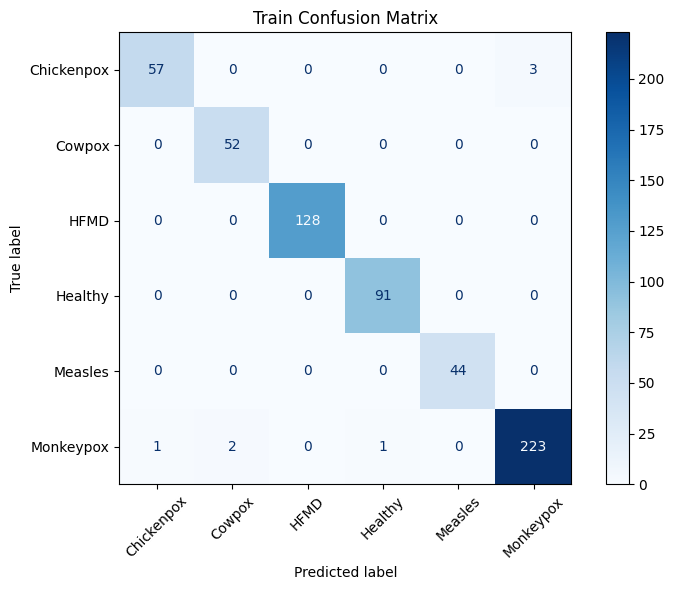

In [15]:

train_metrics = evaluate_model(
    model=model,
    loader=train_eval_loader,
    criterion=criterion,
    device=DEVICE,
    num_classes=NUM_CLASSES,
    use_amp=USE_AMP
)

print_all_metrics(
    metrics=train_metrics,
    class_names=CLASS_NAMES,
    split_name="Train"
)

plot_confusion_matrix(
    metrics=train_metrics,
    class_names=CLASS_NAMES,
    split_name="Train",
    save_path=SAVE_DIR / "train_confusion_matrix.png"
)


/tmp/ipykernel_23/2010429573.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):



===== VALIDATION METRICS =====
Accuracy     : 0.8919
Precision    : 0.8843
Recall       : 0.8536
F1-score     : 0.8659
ROC-AUC      : 0.9557
Sensitivity  : 0.8536
Specificity  : 0.9759
MCC          : 0.8587

Classification Report:
              precision    recall  f1-score   support

  Chickenpox     0.6667    0.5714    0.6154         7
      Cowpox     0.8571    0.8571    0.8571         7
        HFMD     0.8889    1.0000    0.9412        16
     Healthy     1.0000    1.0000    1.0000        11
     Measles     1.0000    0.8000    0.8889         5
   Monkeypox     0.8929    0.8929    0.8929        28

    accuracy                         0.8919        74
   macro avg     0.8843    0.8536    0.8659        74
weighted avg     0.8904    0.8919    0.8893        74

Saved confusion matrix: experiments/resnet18_optimizer_lr_search_v2/validation_confusion_matrix.png


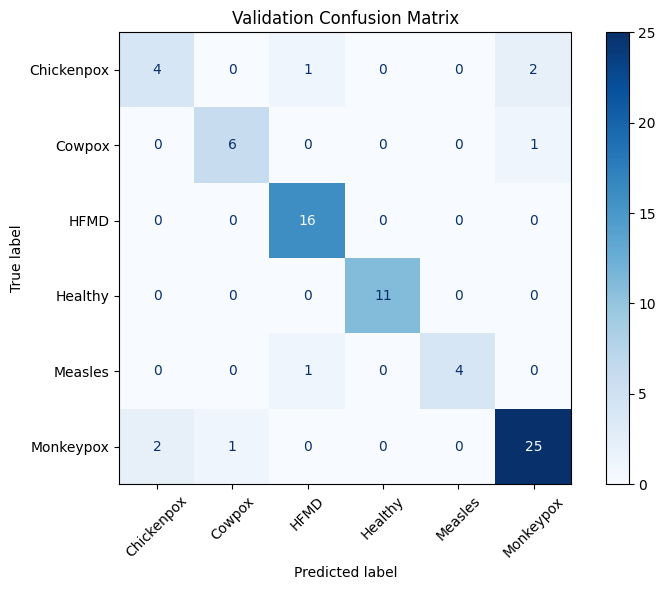

In [16]:
val_metrics = evaluate_model(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=DEVICE,
    num_classes=NUM_CLASSES
)

print_all_metrics(
    metrics=val_metrics,
    class_names=CLASS_NAMES,
    split_name="Validation"
)

plot_confusion_matrix(
    metrics=val_metrics,
    class_names=CLASS_NAMES,
    split_name="Validation",
    save_path=SAVE_DIR / "validation_confusion_matrix.png"
)

/tmp/ipykernel_23/2010429573.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):



===== TEST METRICS =====
Accuracy     : 0.8228
Precision    : 0.8192
Recall       : 0.8069
F1-score     : 0.8032
ROC-AUC      : 0.9553
Sensitivity  : 0.8069
Specificity  : 0.9625
MCC          : 0.7731

Classification Report:
              precision    recall  f1-score   support

  Chickenpox     0.6667    0.7500    0.7059         8
      Cowpox     0.6000    0.8571    0.7059         7
        HFMD     0.8750    0.8235    0.8485        17
     Healthy     0.9167    0.9167    0.9167        12
     Measles     1.0000    0.6667    0.8000         6
   Monkeypox     0.8571    0.8276    0.8421        29

    accuracy                         0.8228        79
   macro avg     0.8192    0.8069    0.8032        79
weighted avg     0.8388    0.8228    0.8257        79

Saved confusion matrix: experiments/resnet18_optimizer_lr_search_v2/test_confusion_matrix.png


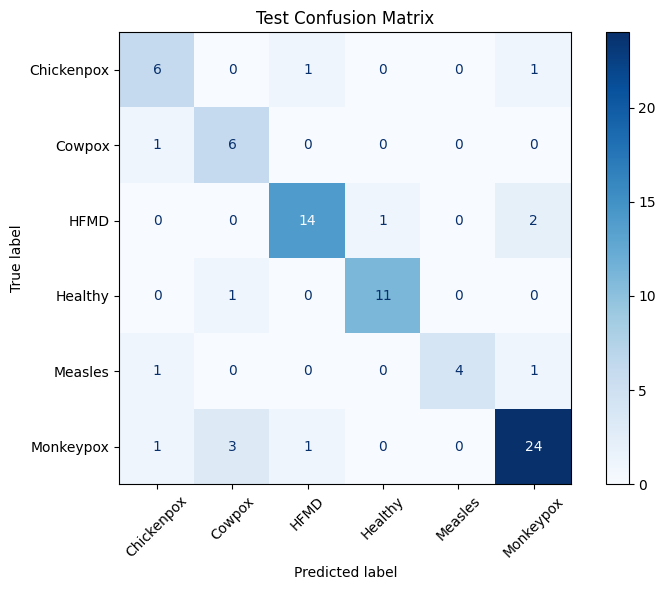

In [17]:
test_metrics = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    num_classes=NUM_CLASSES
)

print_all_metrics(
    metrics=test_metrics,
    class_names=CLASS_NAMES,
    split_name="Test"
)

plot_confusion_matrix(
    metrics=test_metrics,
    class_names=CLASS_NAMES,
    split_name="Test",
    save_path=SAVE_DIR / "test_confusion_matrix.png"
)

In [18]:
import matplotlib.pyplot as plt
import torch
import random

# COLLECT CORRECT / WRONG SAMPLES

def unnormalize_img(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = img_tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)

    return img.permute(1, 2, 0).numpy()


def collect_prediction_samples(model, loader, dataset, device):
    model.eval()

    correct_samples = []
    wrong_samples = []

    sample_idx = 0

    with torch.no_grad():
        for images, labels in loader:
            images_device = images.to(device)
            labels_device = labels.to(device)

            outputs = model(images_device)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            for i in range(images.size(0)):
                img_path = dataset.samples[sample_idx][0]

                item = {
                    "image": images[i],
                    "path": img_path,
                    "true_label": labels[i].item(),
                    "pred_label": preds[i].cpu().item(),
                    "confidence": probs[i][preds[i]].cpu().item()
                }

                if item["true_label"] == item["pred_label"]:
                    correct_samples.append(item)
                else:
                    wrong_samples.append(item)

                sample_idx += 1

    return correct_samples, wrong_samples


correct_samples, wrong_samples = collect_prediction_samples(
    model=model,
    loader=test_loader,
    dataset=test_dataset,
    device=DEVICE
)

print("Correct samples:", len(correct_samples))
print("Wrong samples:", len(wrong_samples))

Correct samples: 65
Wrong samples: 14


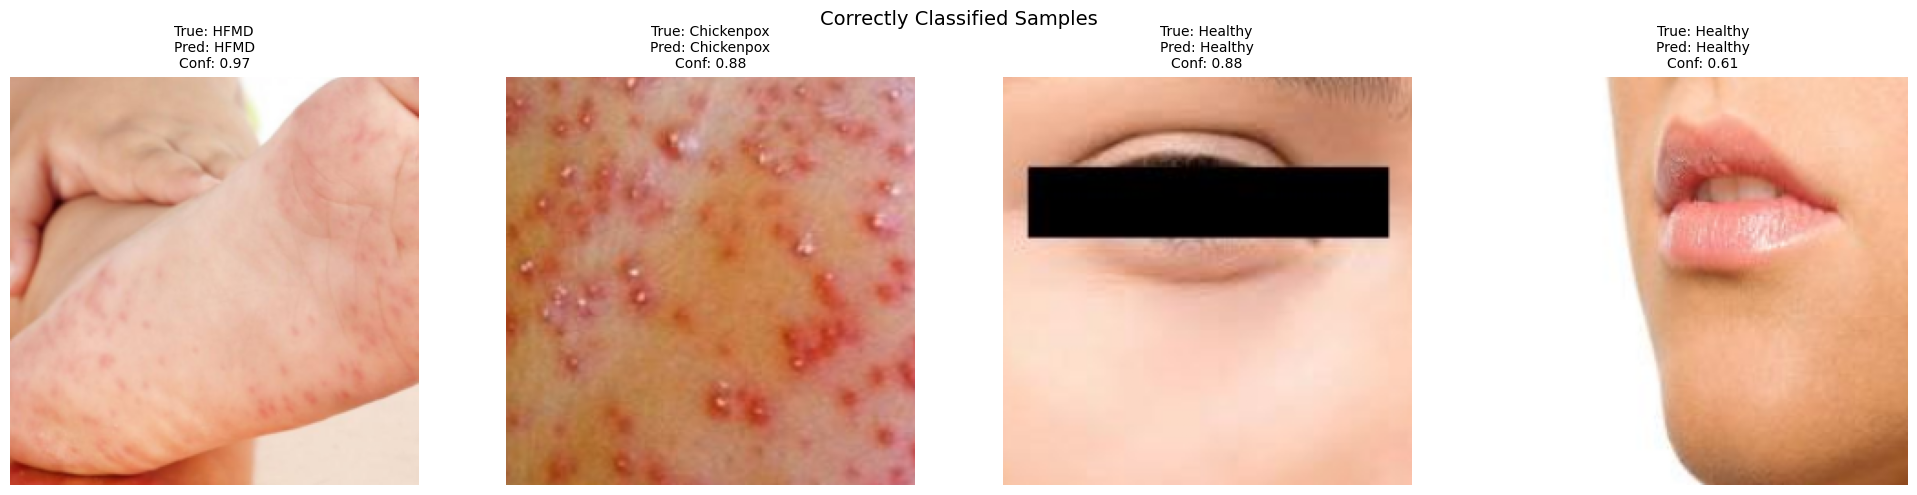

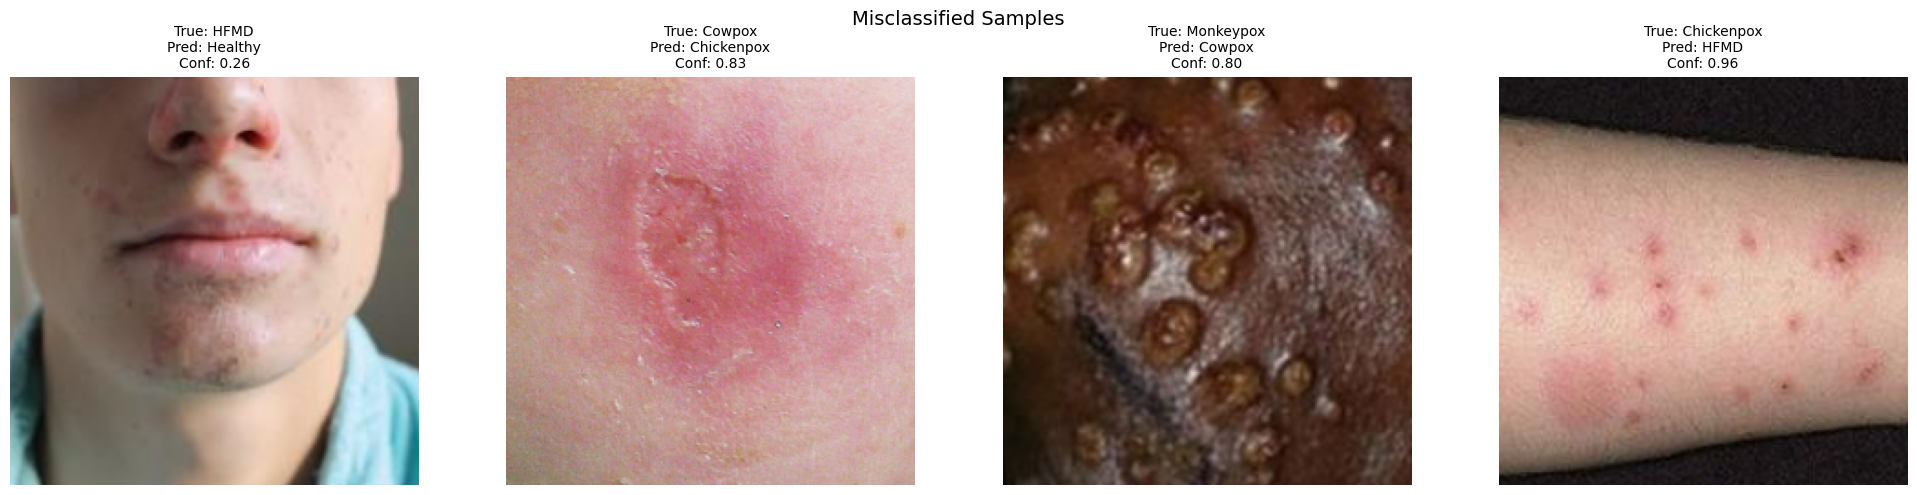

In [19]:
# SHOW 3 CORRECT + 3 WRONG

def show_samples(samples, class_names, title, n=3):
    n = min(n, len(samples))

    selected = random.sample(samples, n)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

    if n == 1:
        axes = [axes]

    for ax, item in zip(axes, selected):
        img = unnormalize_img(item["image"])

        true_name = class_names[item["true_label"]]
        pred_name = class_names[item["pred_label"]]
        conf = item["confidence"]

        ax.imshow(img)
        ax.set_title(
            f"True: {true_name}\nPred: {pred_name}\nConf: {conf:.2f}",
            fontsize=10
        )
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


show_samples(
    samples=correct_samples,
    class_names=CLASS_NAMES,
    title="Correctly Classified Samples",
    n=4
)

show_samples(
    samples=wrong_samples,
    class_names=CLASS_NAMES,
    title="Misclassified Samples",
    n=4
)

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

full_history_df = pd.concat(all_history, ignore_index=True)

history_path = SAVE_DIR / "training_history.csv"

full_history_df.to_csv(history_path, index=False)

print("Saved:", history_path)

display(full_history_df.head())

Saved: experiments/resnet18_optimizer_lr_search_v2/training_history.csv


,experiment_id,run_name,optimizer,initial_lr,weight_decay,epoch,current_lr,train_loss,train_acc,val_loss,val_acc,val_f1,val_precision,val_recall,val_mcc
0,1,Adam_lr1em03_wd0e00,Adam,0.001,0.0,1,0.001,1.391866,0.478405,5.627685,0.148649,0.090488,0.152459,0.147727,-0.026596
1,1,Adam_lr1em03_wd0e00,Adam,0.001,0.0,2,0.001,1.218705,0.598007,3.663385,0.472973,0.409829,0.416195,0.482008,0.368614
2,1,Adam_lr1em03_wd0e00,Adam,0.001,0.0,3,0.001,0.913250,0.669435,1.492866,0.648649,0.571901,0.641324,0.542992,0.533838
3,1,Adam_lr1em03_wd0e00,Adam,0.001,0.0,4,0.001,0.842079,0.722591,1.234378,0.743243,0.712302,0.714983,0.737852,0.683170
4,1,Adam_lr1em03_wd0e00,Adam,0.001,0.0,5,0.001,0.755783,0.745847,2.448793,0.445946,0.496229,0.619969,0.561986,0.426751


Best run: SGD_lr1em02_wd1em04


,experiment_id,run_name,optimizer,initial_lr,weight_decay,epoch,current_lr,train_loss,train_acc,val_loss,val_acc,val_f1,val_precision,val_recall,val_mcc
173,9,SGD_lr1em02_wd1em04,SGD,0.01,0.0001,1,0.01,1.577908,0.352159,1.308081,0.608108,0.552206,0.558405,0.601569,0.530217
174,9,SGD_lr1em02_wd1em04,SGD,0.01,0.0001,2,0.01,0.853859,0.717608,1.369620,0.594595,0.550893,0.559954,0.617992,0.522325
175,9,SGD_lr1em02_wd1em04,SGD,0.01,0.0001,3,0.01,0.739020,0.762458,1.337841,0.675676,0.653730,0.683170,0.685714,0.616288
176,9,SGD_lr1em02_wd1em04,SGD,0.01,0.0001,4,0.01,0.668560,0.807309,1.507476,0.621622,0.613341,0.693474,0.683685,0.573986
177,9,SGD_lr1em02_wd1em04,SGD,0.01,0.0001,5,0.01,0.606935,0.848837,1.157745,0.756757,0.705218,0.722375,0.716423,0.686893


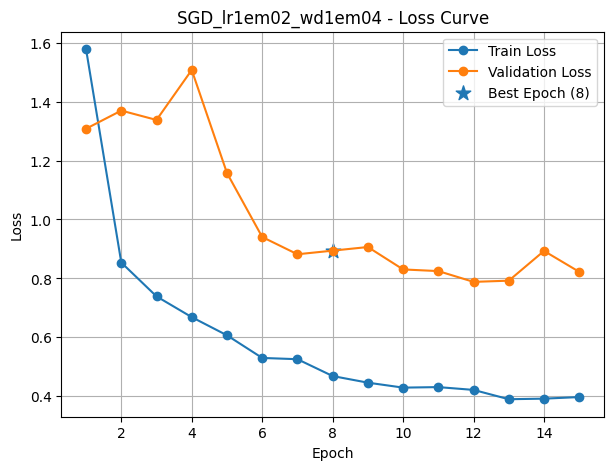

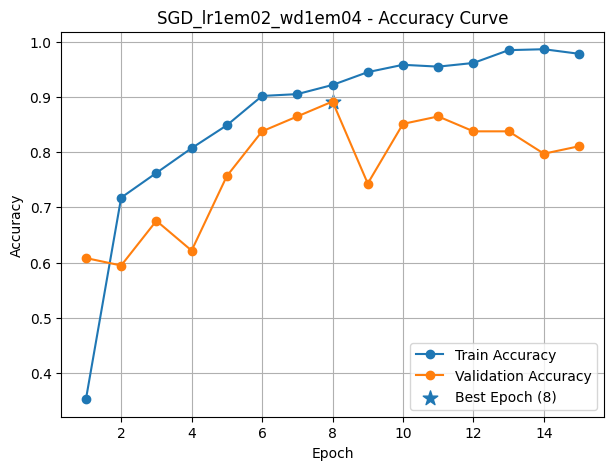

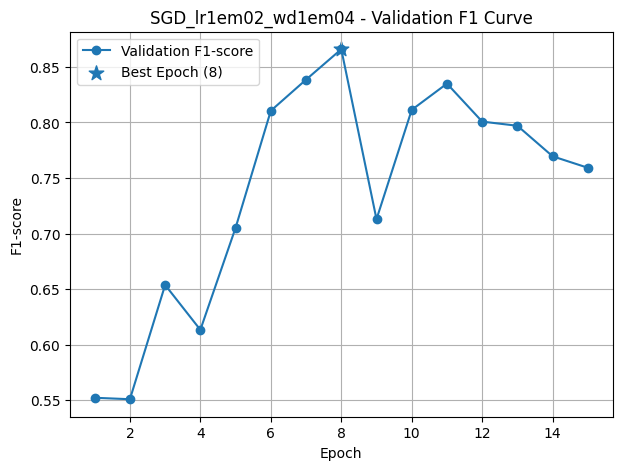

In [21]:

import matplotlib.pyplot as plt

best_run_name = best_overall_info["run_name"]

best_history_df = full_history_df[
    full_history_df["run_name"] == best_run_name
].copy()

print("Best run:", best_run_name)

display(best_history_df.head())

plt.figure(figsize=(7, 5))

plt.plot(
    best_history_df["epoch"],
    best_history_df["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    best_history_df["epoch"],
    best_history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

best_epoch = best_overall_info["best_epoch"]

best_row = best_history_df[
    best_history_df["epoch"] == best_epoch
].iloc[0]

plt.scatter(
    best_epoch,
    best_row["val_loss"],
    s=120,
    marker="*",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{best_run_name} - Loss Curve")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(7, 5))

plt.plot(
    best_history_df["epoch"],
    best_history_df["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    best_history_df["epoch"],
    best_history_df["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.scatter(
    best_epoch,
    best_row["val_acc"],
    s=120,
    marker="*",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{best_run_name} - Accuracy Curve")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(7, 5))

plt.plot(
    best_history_df["epoch"],
    best_history_df["val_f1"],
    marker="o",
    label="Validation F1-score"
)

plt.scatter(
    best_epoch,
    best_row["val_f1"],
    s=120,
    marker="*",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title(f"{best_run_name} - Validation F1 Curve")
plt.legend()
plt.grid(True)

plt.show()
